# 02 — Topic Modeling with BERTopic

**MO850 Final Project** — Semantic Search of Vaccine Disinformation Narratives

This notebook applies BERTopic to the filtered Aletheia dataset to automatically discover latent topics in the corpus. The discovered topics are then compared against manually defined narrative queries to evaluate coverage and identify unexpected themes.

**Key questions:**
- What are the dominant topics in anti-vaccine Telegram channels?
- Do the manually defined narrative queries cover the main topics?
- Are there narratives that only emerge through automated topic discovery?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('Dependencies loaded successfully.')

Dependencies loaded successfully.


## 1. Load Filtered Dataset

In [2]:
df = pd.read_csv('aletheia_filtered.csv')
print(f'Loaded {len(df):,} messages')
print(f'Columns: {list(df.columns)}')

# Extract the text corpus as a list
docs = df['text_content'].tolist()
print(f'Corpus size: {len(docs):,} documents')
print(f'Average tokens per document: {df["n_tokens"].mean():.0f}')

Loaded 17,712 messages
Columns: ['channel_id', 'message_id', 'date', 'date_parsed', 'date_dt', 'text_content', 'n_tokens', 'language', 'is_vaccine_related', 'n_forwards', 'views', 'reactions', 'forward_from', 'reply_to', 'media_type']
Corpus size: 17,712 documents
Average tokens per document: 71


## 2. Configure and Run BERTopic

BERTopic internally uses:
1. **SBERT** to generate document embeddings
2. **UMAP** to reduce dimensionality
3. **HDBSCAN** to cluster documents
4. **c-TF-IDF** to extract representative terms per cluster

We configure each component explicitly for reproducibility and control.

In [3]:
# Step 1: Embedding model (multilingual SBERT)
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Pre-compute embeddings (saves time if we need to re-run BERTopic with different params)
print('Generating embeddings... (this may take 5-10 minutes)')
embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f'Embeddings shape: {embeddings.shape}')

# Save embeddings for reuse in notebook 03
np.save('embeddings_filtered.npy', embeddings)
print('Embeddings saved to embeddings_filtered.npy')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Generating embeddings... (this may take 5-10 minutes)


Batches:   0%|          | 0/277 [00:00<?, ?it/s]

Embeddings shape: (17712, 384)
Embeddings saved to embeddings_filtered.npy


In [4]:
# Step 2: Dimensionality reduction (UMAP)
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# Step 3: Clustering (HDBSCAN)
hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric='euclidean',
    prediction_data=True,
    core_dist_n_jobs=1
)

# Step 4: Tokenizer for c-TF-IDF (Portuguese-aware)
# Using basic stopwords to improve topic quality
pt_stopwords = [
    'de',
    'do',
    'da',
    'em',
    'um',
    'uma',
    'no',
    'na',
    'os',
    'as',
    'dos',
    'das',
    'nos',
    'nas',
    'com',
    'por',
    'para',
    'pelo',
    'pela',
    'pelos',
    'pelas',
    'ao',
    'aos',
    'à',
    'as',
    'que',
    'não',
    'mais',
    'como',
    'mas',
    'foi',
    'ser',
    'ter',
    'são',
    'está',
    'isso',
    'pode',
    'tem',
    'vai',
    'sobre',
    'entre',
    'também',
    'muito',
    'ainda',
    'quando',
    'onde',
    'porque',
    'então',
    'já',
    'sem',
    'até',
    'sua',
    'seu',
    'seus',
    'suas',
    'ele',
    'ela',
    'eles',
    'elas',
    'isso',
    'esta',
    'este',
    'esse',
    'essa',
    'mesmo',
    'cada',
    'desde',
    'depois',
    'antes',
    'apenas',
    'sempre',
    'todos',
    'todas',
    'todo',
    'toda',
    'outro',
    'outra',
    'outros',
    'outras',
    'agora',
    'aqui',
    'assim',
    'bem',
    'pra',
    'pro',
    'dia',
    'vez',
    'nosso',
    'nossa',
    'nossos',
    'nossas',
    'você',
    'vocês',
    'gente',
    'tudo',
    'nada',
    'fazer',
    'sendo',
    'estão',
    'seria',
    'grande',
    'parte',
    'forma',
    'tipo',
    'ano',
    'anos',
    'contra',
    'novo',
    'nova',
    'se',
    'me',
    'ou',
    'mim',
    'te',
    'lhe',
    'seja',
    'qual',
    'quais',
    'quem',
    'cujo'
]

vectorizer_model = CountVectorizer(
    stop_words=pt_stopwords,
    min_df=5,
    ngram_range=(1, 2)  # unigrams and bigrams
)

print('BERTopic components configured.')

BERTopic components configured.


In [5]:
# Step 5: Fit BERTopic
print('Fitting BERTopic model... (this may take a few minutes)')

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

n_topics = len(set(topics)) - (1 if -1 in topics else 0)  # exclude outlier topic -1
n_outliers = topics.count(-1)
print(f'\nDiscovered {n_topics} topics')
print(f'Outlier documents (topic -1): {n_outliers:,} ({n_outliers/len(docs)*100:.1f}%)')

2026-06-29 14:37:35,435 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic model... (this may take a few minutes)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-06-29 14:37:55,940 - BERTopic - Dimensionality - Completed ✓
2026-06-29 14:37:55,941 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-29 14:37:56,340 - BERTopic - Cluster - Completed ✓
2026-06-29 14:37:56,343 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-29 14:37:57,496 - BERTopic - Representation - Completed ✓



Discovered 78 topics
Outlier documents (topic -1): 8,363 (47.2%)


## 3. Topic Overview

In [6]:
# Get topic info
topic_info = topic_model.get_topic_info()
print(f'Topic summary (top 20):\n')
topic_info.head(20)

Topic summary (top 20):



,Topic,Count,Name,Representation,Representative_Docs
0,-1,8363,-1_https_channel_hash_pessoas_vacina,"[https, channel_hash, pessoas, vacina, covid, ...",[Vamos acordar pra realidade.\nMuita gente ain...
1,0,1061,0_deus_jesus_vida_senhor,"[deus, jesus, vida, senhor, eu, cristo, igreja...",[Jesus já preparou tudo Maria. (I Coríntios C...
2,1,880,1_rússia_ucrânia_putin_russo,"[rússia, ucrânia, putin, russo, otan, guerra, ...","[👀\n\n🇷🇺 O presidente russo Putin diz que, se ..."
3,2,358,2_brasil_brasileiro_povo_brasileiros,"[brasil, brasileiro, povo, brasileiros, https,...",[JAIR BOLSONARO E A NOM\nO jogo político no Br...
4,3,314,3_morre_morreu_após_infarto,"[morre, morreu, após, infarto, morte, hospital...",[🇧🇷👁💉☠️ Sobrinho da prefeita de Santana do Pia...
5,4,281,4_mundial_oms_2030_agenda,"[mundial, oms, 2030, agenda, global, mundo, sa...",[Aprovar pactos comerciais globais que ignoram...
6,5,277,5_vacina_vacinas_vacinados_vacinação,"[vacina, vacinas, vacinados, vacinação, pessoa...","[👉 https://is.gd/RB6nqG\n\n""Carro da Vacina"" o..."
7,6,271,6_crianças_mulheres_mulher_lgbt,"[crianças, mulheres, mulher, lgbt, filhos, tra...","[Eles querem substituir sexo biológico, que é ..."
8,7,232,7_trump_donald_donald trump_presidente,"[trump, donald, donald trump, presidente, pres...",[A ex-Primeira-Dama Hillary Clinton chama Trum...
9,8,232,8_bolsonaro_jair_jair bolsonaro_presidente,"[bolsonaro, jair, jair bolsonaro, presidente, ...",[esse foi o governador mais triste que o Maran...


In [7]:
# Top 10 topics - representative terms
print('=== Top 10 Topics — Representative Terms ===\n')
for topic_id in range(min(10, n_topics)):
    terms = topic_model.get_topic(topic_id)
    term_str = ', '.join([f'{t[0]} ({t[1]:.3f})' for t in terms[:8]])
    count = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    print(f'Topic {topic_id} ({count:,} docs): {term_str}')
    print()

=== Top 10 Topics — Representative Terms ===

Topic 0 (1,061 docs): deus (0.030), jesus (0.018), vida (0.015), senhor (0.014), eu (0.012), cristo (0.012), igreja (0.011), bíblia (0.010)

Topic 1 (880 docs): rússia (0.045), ucrânia (0.045), putin (0.032), russo (0.023), otan (0.018), guerra (0.016), russos (0.016), zelensky (0.015)

Topic 2 (358 docs): brasil (0.044), brasileiro (0.018), povo (0.014), brasileiros (0.010), https (0.010), channel_hash (0.009), mundo (0.009), liberdade (0.008)

Topic 3 (314 docs): morre (0.043), morreu (0.033), após (0.022), infarto (0.020), morte (0.019), hospital (0.018), mal (0.018), faleceu (0.017)

Topic 4 (281 docs): mundial (0.024), oms (0.016), 2030 (0.013), agenda (0.013), global (0.012), mundo (0.012), saúde (0.010), onu (0.009)

Topic 5 (277 docs): vacina (0.039), vacinas (0.038), vacinados (0.021), vacinação (0.015), pessoas (0.013), vacinar (0.010), lote (0.010), acionista (0.009)

Topic 6 (271 docs): crianças (0.031), mulheres (0.025), mulher

In [8]:
# Bar chart of top terms per topic (top 8 topics)
fig = topic_model.visualize_barchart(
    top_n_topics=8,
    n_words=8,
    title='Top Terms per Topic (Top 8 Topics)'
)
fig.write_image('figures/02_topic_barchart.png', scale=2, width=1200, height=800)
fig.show()

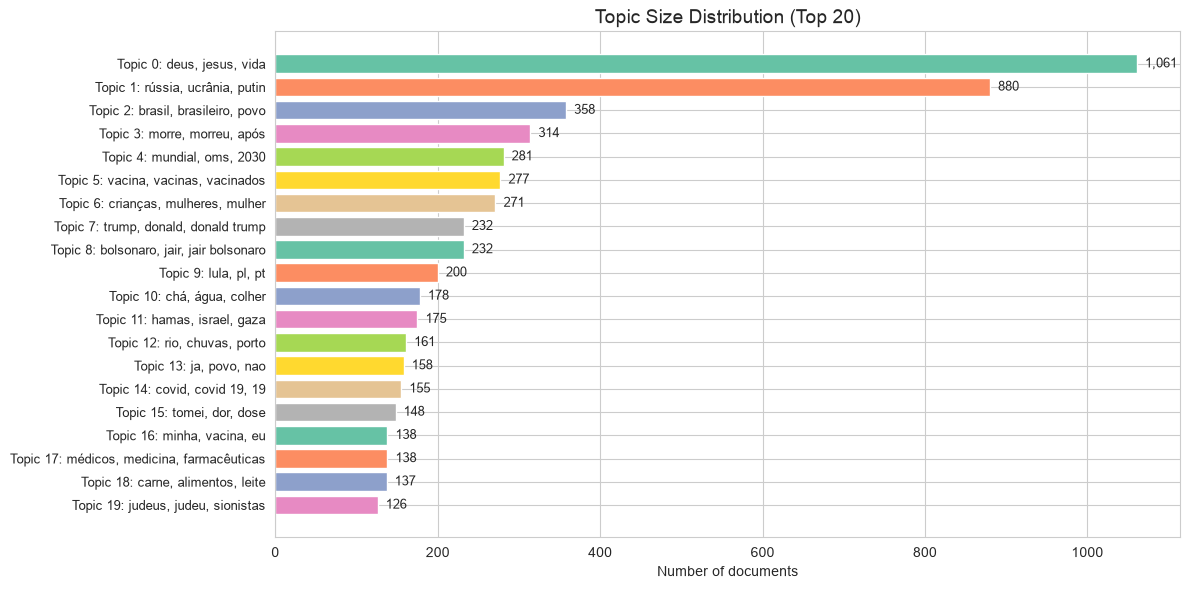

In [9]:
# Topic size distribution
fig, ax = plt.subplots(figsize=(12, 6))
topic_sizes = topic_info[topic_info['Topic'] != -1].sort_values('Count', ascending=False).head(20)
ax.barh(range(len(topic_sizes)), topic_sizes['Count'].values, color=sns.color_palette('Set2', len(topic_sizes)))
ax.set_yticks(range(len(topic_sizes)))
# Build labels: Topic ID + first 3 terms
labels = []
for _, row in topic_sizes.iterrows():
    tid = row['Topic']
    terms = topic_model.get_topic(tid)
    top3 = ', '.join([t[0] for t in terms[:3]])
    labels.append(f'Topic {tid}: {top3}')
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_title('Topic Size Distribution (Top 20)', fontsize=14)
ax.set_xlabel('Number of documents')
for i, v in enumerate(topic_sizes['Count'].values):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/02_topic_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Topic Visualization (Intertopic Distance Map)

In [10]:
# Intertopic distance map (2D projection of topic centroids)
fig = topic_model.visualize_topics(title='Intertopic Distance Map')
fig.write_image('figures/02_intertopic_map.png', scale=2, width=900, height=700)
fig.show()

In [11]:
# Topic hierarchy (dendrogram)
fig = topic_model.visualize_hierarchy(top_n_topics=20, title='Topic Hierarchy (Top 20)')
fig.write_image('figures/02_topic_hierarchy.png', scale=2, width=1200, height=600)
fig.show()

## 5. Mapping: BERTopic Topics ↔ Manual Narrative Queries

The following are the **manually defined narrative queries**. We now compare them against the automatically discovered topics to evaluate coverage.

| # | Manual Narrative Query |
|---|---|
| Q1 | "Vacinas causam doenças autoimunes" |
| Q2 | "Vacinas contêm microchips ou substâncias ocultas" |
| Q3 | "O governo esconde os efeitos colaterais das vacinas" |
| Q4 | "As vacinas contra COVID foram desenvolvidas rápido demais e não são seguras" |
| Q5 | "A indústria farmacêutica lucra com as vacinas às custas da saúde pública" |

In [12]:
# Use semantic similarity to find which topics are closest to each narrative query
narrative_queries = {
    'Q1': 'Vacinas causam doenças autoimunes',
    'Q2': 'Vacinas contêm microchips ou substâncias ocultas',
    'Q3': 'Governos escondem os efeitos colaterais das vacinas',
    'Q4': 'A imunidade natural é superior à imunidade vacinal',
    'Q5': 'Vacinas foram desenvolvidas rápido demais e não são seguras'
}

# Find similar topics for each query
print('=== Narrative Query → Most Similar Topics ===\n')
mapping_results = []
for qid, query in narrative_queries.items():
    similar_topics, similarity = topic_model.find_topics(query, top_n=3)
    print(f'{qid}: "{query}"')
    for tid, sim in zip(similar_topics, similarity):
        if tid == -1:
            continue
        terms = topic_model.get_topic(tid)
        top_terms = ', '.join([t[0] for t in terms[:5]])
        count = topic_info[topic_info['Topic'] == tid]['Count'].values[0]
        print(f'  → Topic {tid} (sim={sim:.3f}, {count:,} docs): {top_terms}')
        mapping_results.append({
            'Query': qid,
            'Query_text': query,
            'Topic_ID': tid,
            'Similarity': sim,
            'Top_terms': top_terms,
            'Doc_count': count
        })
    print()

mapping_df = pd.DataFrame(mapping_results)
mapping_df


=== Narrative Query → Most Similar Topics ===

Q1: "Vacinas causam doenças autoimunes"
  → Topic 5 (sim=0.696, 277 docs): vacina, vacinas, vacinados, vacinação, pessoas
  → Topic 16 (sim=0.667, 138 docs): minha, vacina, eu, tomar, tenho
  → Topic 40 (sim=0.651, 81 docs): ivermectina, mrna, spike, proteína, vacinas

Q2: "Vacinas contêm microchips ou substâncias ocultas"
  → Topic 40 (sim=0.688, 81 docs): ivermectina, mrna, spike, proteína, vacinas
  → Topic 5 (sim=0.675, 277 docs): vacina, vacinas, vacinados, vacinação, pessoas
  → Topic 68 (sim=0.610, 32 docs): pfizer, vacina, vacinas, vacinas pfizer, farmacêutica

Q3: "Governos escondem os efeitos colaterais das vacinas"
  → Topic 5 (sim=0.840, 277 docs): vacina, vacinas, vacinados, vacinação, pessoas
  → Topic 43 (sim=0.753, 72 docs): vacina, crianças, vacinadas, filhos, vacinação
  → Topic 41 (sim=0.742, 73 docs): vacina, vacinação, brasil, vacinas, bolsonaro

Q4: "A imunidade natural é superior à imunidade vacinal"
  → Topic 5 (sim

,Query,Query_text,Topic_ID,Similarity,Top_terms,Doc_count
0,Q1,Vacinas causam doenças autoimunes,5,0.696250,"vacina, vacinas, vacinados, vacinação, pessoas",277
1,Q1,Vacinas causam doenças autoimunes,16,0.667109,"minha, vacina, eu, tomar, tenho",138
2,Q1,Vacinas causam doenças autoimunes,40,0.651149,"ivermectina, mrna, spike, proteína, vacinas",81
3,Q2,Vacinas contêm microchips ou substâncias ocultas,40,0.687585,"ivermectina, mrna, spike, proteína, vacinas",81
4,Q2,Vacinas contêm microchips ou substâncias ocultas,5,0.675272,"vacina, vacinas, vacinados, vacinação, pessoas",277
5,Q2,Vacinas contêm microchips ou substâncias ocultas,68,0.609535,"pfizer, vacina, vacinas, vacinas pfizer, farma...",32
6,Q3,Governos escondem os efeitos colaterais das va...,5,0.839908,"vacina, vacinas, vacinados, vacinação, pessoas",277
7,Q3,Governos escondem os efeitos colaterais das va...,43,0.753343,"vacina, crianças, vacinadas, filhos, vacinação",72
8,Q3,Governos escondem os efeitos colaterais das va...,41,0.741517,"vacina, vacinação, brasil, vacinas, bolsonaro",73
9,Q4,A imunidade natural é superior à imunidade vac...,5,0.697156,"vacina, vacinas, vacinados, vacinação, pessoas",277


In [13]:
# Identify topics NOT covered by any manual query (potential blind spots)
mapped_topics = set(mapping_df['Topic_ID'].unique())
all_topics = set(topic_info[topic_info['Topic'] != -1]['Topic'].values)
unmapped_topics = all_topics - mapped_topics

print(f'Total topics discovered: {len(all_topics)}')
print(f'Topics mapped to manual queries: {len(mapped_topics)}')
print(f'Topics NOT covered by any query: {len(unmapped_topics)}')
print(f'\n=== Unmapped Topics (potential blind spots) ===\n')

# Show top 10 unmapped topics by size
unmapped_info = topic_info[topic_info['Topic'].isin(unmapped_topics)].sort_values('Count', ascending=False).head(10)
for _, row in unmapped_info.iterrows():
    tid = row['Topic']
    terms = topic_model.get_topic(tid)
    top_terms = ', '.join([t[0] for t in terms[:6]])
    print(f'Topic {tid} ({row["Count"]:,} docs): {top_terms}')

Total topics discovered: 78
Topics mapped to manual queries: 6
Topics NOT covered by any query: 72

=== Unmapped Topics (potential blind spots) ===

Topic 0 (1,061 docs): deus, jesus, vida, senhor, eu, cristo
Topic 1 (880 docs): rússia, ucrânia, putin, russo, otan, guerra
Topic 2 (358 docs): brasil, brasileiro, povo, brasileiros, https, channel_hash
Topic 3 (314 docs): morre, morreu, após, infarto, morte, hospital
Topic 4 (281 docs): mundial, oms, 2030, agenda, global, mundo
Topic 6 (271 docs): crianças, mulheres, mulher, lgbt, filhos, trans
Topic 7 (232 docs): trump, donald, donald trump, presidente, presidente trump, fbi
Topic 8 (232 docs): bolsonaro, jair, jair bolsonaro, presidente, presidente jair, presidente bolsonaro
Topic 9 (200 docs): lula, pl, pt, brasil, janja, governo
Topic 10 (178 docs): chá, água, colher, óleo, corpo, diabetes


## 6. Representative Documents per Topic

In [14]:
# Show representative documents for the top 5 topics
print('=== Representative Documents (Top 5 Topics) ===\n')
for topic_id in range(min(5, n_topics)):
    terms = topic_model.get_topic(topic_id)
    top3 = ', '.join([t[0] for t in terms[:3]])
    count = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    print(f'--- Topic {topic_id} ({count:,} docs): {top3} ---')
    # Get indices of documents in this topic
    topic_docs_idx = [i for i, t in enumerate(topics) if t == topic_id]
    # Sample 3 representative documents
    sample_idx = np.random.RandomState(42).choice(topic_docs_idx, size=min(3, len(topic_docs_idx)), replace=False)
    for idx in sample_idx:
        print(f'  [{idx}] {docs[idx][:200]}...')
    print()

=== Representative Documents (Top 5 Topics) ===

--- Topic 0 (1,061 docs): deus, jesus, vida ---
  [512] Representações de Moloch

A atitude sanguinária feita nas cerimônias do passado em nome de Moloch fez com que ele ganhasse certa popularidade. Ele acabou sendo retratado na Bíblia e em obras de autore...
  [5733] -> AVISO FINAL <-
• A NOITE DA ALMA, EPISÓDIO 5 - (17/02)

Mas eu vos digo que toda a palavra ociosa que os homens disserem hão de dar conta no dia do juízo.
[Mateus 12:36]...
  [7485] Papa diz que homossexualidade não é crime, mas é pecado

O papa Francisco se pronunciou sobre a homossexualidade declarando que trata-se de um “pecado”, mas não um “crime”.

Em entrevista à Associated...

--- Topic 1 (880 docs): rússia, ucrânia, putin ---
  [9418] 🌩

💥💥💥💥💥💥

By Rafapal 


Atenção.
O presidente sul-africano diz explicitamente que "da próxima reunião do BRICS sairá uma nova ordem financeira mundial que impeça sanções como as que a Rússia está sof...
  [8088] 🌩

🇺🇸🇷🇺Os Estados U

## 7. Temporal Topic Evolution

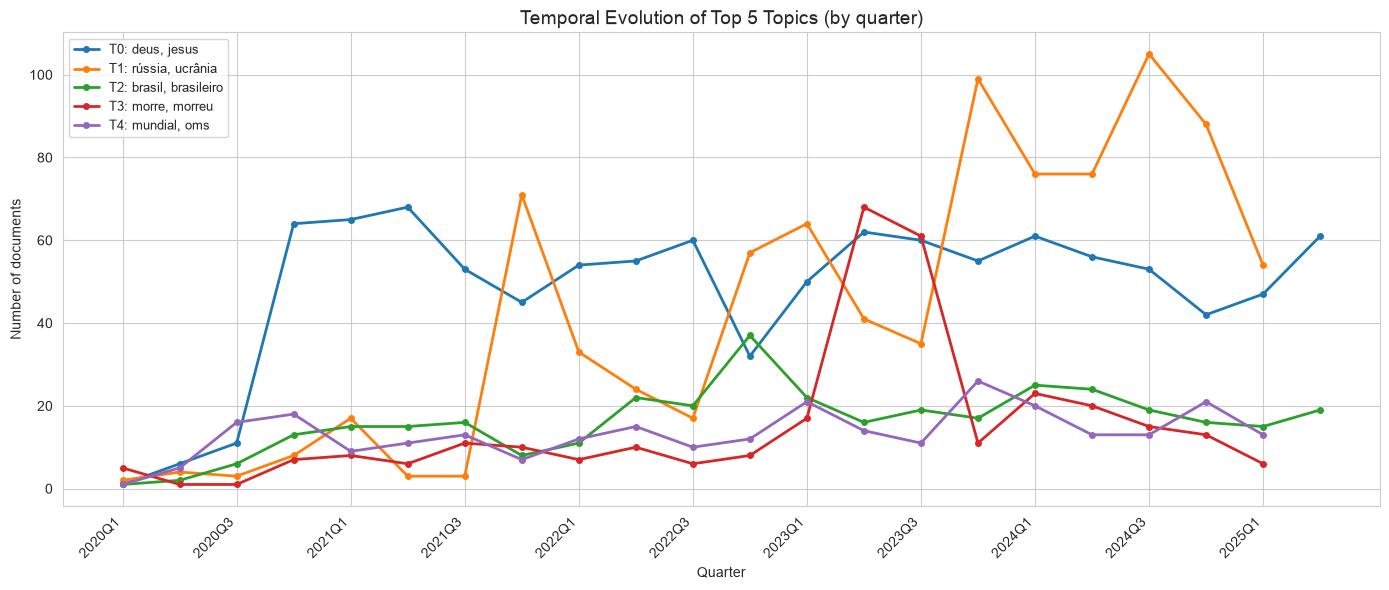

In [15]:
# Temporal evolution of top topics
df['topic'] = topics
df['date_dt'] = pd.to_datetime(df['date_parsed'], format='%Y/%m/%d %H:%M:%S', errors='coerce')

# Get the top 5 topics (excluding outliers)
top5_topics = topic_info[topic_info['Topic'] != -1].head(5)['Topic'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for tid in top5_topics:
    topic_docs = df[df['topic'] == tid]
    monthly = topic_docs.groupby(topic_docs['date_dt'].dt.to_period('Q')).size()
    terms = topic_model.get_topic(tid)
    label = f'T{tid}: {", ".join([t[0] for t in terms[:2]])}'
    ax.plot(range(len(monthly)), monthly.values, marker='o', markersize=4, linewidth=2, label=label)

ax.set_title('Temporal Evolution of Top 5 Topics (by quarter)', fontsize=14)
ax.set_xlabel('Quarter')
ax.set_ylabel('Number of documents')
# X-axis labels
quarters = df[df['topic'].isin(top5_topics)].groupby(df['date_dt'].dt.to_period('Q')).size()
q_labels = [str(q) for q in quarters.index]
step = max(1, len(q_labels) // 10)
ax.set_xticks(range(0, len(q_labels), step))
ax.set_xticklabels([q_labels[i] for i in range(0, len(q_labels), step)], rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('figures/02_temporal_topics.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis Notes

After running the model with min_topic_size=30, the results are much clearer. 
The most striking observation is Topic 0, which is almost entirely religious (deus, jesus, senhor). This suggests a strong intersection between faith-based discourse and vaccine hesitancy in these channels, which wasn't explicitly in our initial search queries.

Topic 40 (mRNA, spike, protein) seems to be the main technical cluster. It connects Q1, Q2, and Q4, showing that biological arguments are the shared foundation for these specific narratives. Also, the government and pharma-related queries (Q3, Q5) point to Topic 43, which is focused on children—likely the main emotional driver for these attacks.

The embeddings are saved and ready for the semantic search phase. The mapping validates that the manual queries make sense in this context, even if some topics are still broad.